In [13]:
file_path = r'..\base_anonimizada\Ivcad\df_fam_ivcad.csv'
df1 = pd.read_csv(file_path)
df1.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,RF_CAD,CO_IBGE_REG,CO_IBGE_UF,CO_IBGE_MUN,IN_NECESSIDADE_CUIDADOS_1,IN_NECESSIDADE_CUIDADOS_2,IN_NECESSIDADE_CUIDADOS_3,IN_NECESSIDADE_CUIDADOS_4,...,IN_CONDICOES_HABITACIONAIS_5,IN_CONDICOES_HABITACIONAIS_6,IN_CONDICOES_HABITACIONAIS_7,IN_CONDICOES_HABITACIONAIS_8,IN_CONDICOES_HABITACIONAIS_9,IN_CONDICOES_HABITACIONAIS_10,IN_CONDICOES_HABITACIONAIS_11,IN_CONDICOES_HABITACIONAIS_12,IN_CONDICOES_HABITACIONAIS_13,IN_CONDICOES_HABITACIONAIS_14
0,1,396.0,202511,1,11,1100205,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
1,2,0.0,202511,1,11,1100205,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,3,507.0,202511,1,11,1100205,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,81.0,202511,1,11,1100122,1,1,1,0,...,0,0,1,0,0,0,0,0,1,1
4,5,212.0,202511,1,11,1100122,1,1,1,0,...,0,0,1,0,0,1,0,0,0,0


In [14]:
df1.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'RF_CAD', 'CO_IBGE_REG',
       'CO_IBGE_UF', 'CO_IBGE_MUN', 'IN_NECESSIDADE_CUIDADOS_1',
       'IN_NECESSIDADE_CUIDADOS_2', 'IN_NECESSIDADE_CUIDADOS_3',
       'IN_NECESSIDADE_CUIDADOS_4', 'IN_NECESSIDADE_CUIDADOS_5',
       'IN_NECESSIDADE_CUIDADOS_6', 'IN_NECESSIDADE_CUIDADOS_7',
       'IN_DES_PRIMEIRA_INFANCIA_1', 'IN_DES_PRIMEIRA_INFANCIA_2',
       'IN_DES_PRIMEIRA_INFANCIA_3', 'IN_DES_CRIANCA_ADOLESCENTE_1',
       'IN_DES_CRIANCA_ADOLESCENTE_2', 'IN_DES_CRIANCA_ADOLESCENTE_3',
       'IN_DES_CRIANCA_ADOLESCENTE_4', 'IN_DES_CRIANCA_ADOLESCENTE_5',
       'IN_TRAB_QUALIF_ADULTOS_1', 'IN_TRAB_QUALIF_ADULTOS_2',
       'IN_TRAB_QUALIF_ADULTOS_3', 'IN_TRAB_QUALIF_ADULTOS_4',
       'IN_TRAB_QUALIF_ADULTOS_5', 'IN_TRAB_QUALIF_ADULTOS_6',
       'IN_TRAB_QUALIF_ADULTOS_7', 'IN_CONDICOES_HABITACIONAIS_1',
       'IN_CONDICOES_HABITACIONAIS_2', 'IN_CONDICOES_HABITACIONAIS_5',
       'IN_CONDICOES_HABITACIONAIS_6', 'IN_CONDICOES_HABITACIONAIS

In [15]:
import numpy as np

# Definir condições
condicoes = [
    df1['VL_RENDA_MEDIA_FAM'] <= 218,                      # 0 - pobreza
    (df1['VL_RENDA_MEDIA_FAM'] > 218) & (df['VL_RENDA_MEDIA_FAM'] <= 759),  # 1 - baixa renda
    df1['VL_RENDA_MEDIA_FAM'] > 759                       # 2 - acima de 1/2 salário mínimo
]

# Valores correspondentes
valores = [0, 1, 2]

# Criar a nova coluna
df1['classe_renda'] = np.select(condicoes, valores)



In [16]:
df1.groupby('classe_renda')['ID_FAM_ANON'].nunique()


classe_renda
0    1265698
1    2379691
Name: ID_FAM_ANON, dtype: int64

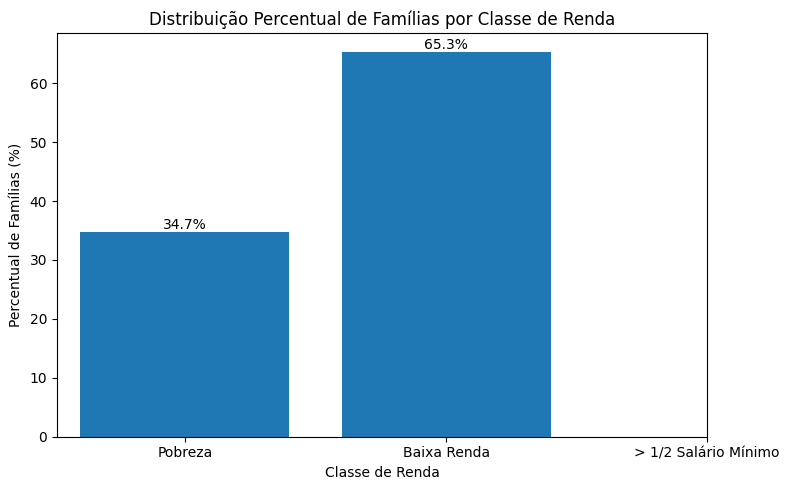

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Contar famílias únicas por classe de renda
familias_por_classe = (
    df1.groupby('classe_renda')['ID_FAM_ANON']
      .nunique()
      .reset_index(name='qt_familias')
)

# 2) Calcular percentuais
total_familias = familias_por_classe['qt_familias'].sum()
familias_por_classe['percentual'] = (
    familias_por_classe['qt_familias'] / total_familias * 100
)

# 3) Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(
    familias_por_classe['classe_renda'],
    familias_por_classe['percentual']
)

# Rótulos e formatação
plt.xlabel("Classe de Renda")
plt.ylabel("Percentual de Famílias (%)")
plt.title("Distribuição Percentual de Famílias por Classe de Renda")
plt.xticks([0,1,2], ["Pobreza", "Baixa Renda", "> 1/2 Salário Mínimo"])

# Mostrar valores no topo das barras
for i, v in enumerate(familias_por_classe['percentual']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()



In [23]:
df1.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'RF_CAD', 'CO_IBGE_REG',
       'CO_IBGE_UF', 'CO_IBGE_MUN', 'IN_NECESSIDADE_CUIDADOS_1',
       'IN_NECESSIDADE_CUIDADOS_2', 'IN_NECESSIDADE_CUIDADOS_3',
       'IN_NECESSIDADE_CUIDADOS_4', 'IN_NECESSIDADE_CUIDADOS_5',
       'IN_NECESSIDADE_CUIDADOS_6', 'IN_NECESSIDADE_CUIDADOS_7',
       'IN_DES_PRIMEIRA_INFANCIA_1', 'IN_DES_PRIMEIRA_INFANCIA_2',
       'IN_DES_PRIMEIRA_INFANCIA_3', 'IN_DES_CRIANCA_ADOLESCENTE_1',
       'IN_DES_CRIANCA_ADOLESCENTE_2', 'IN_DES_CRIANCA_ADOLESCENTE_3',
       'IN_DES_CRIANCA_ADOLESCENTE_4', 'IN_DES_CRIANCA_ADOLESCENTE_5',
       'IN_TRAB_QUALIF_ADULTOS_1', 'IN_TRAB_QUALIF_ADULTOS_2',
       'IN_TRAB_QUALIF_ADULTOS_3', 'IN_TRAB_QUALIF_ADULTOS_4',
       'IN_TRAB_QUALIF_ADULTOS_5', 'IN_TRAB_QUALIF_ADULTOS_6',
       'IN_TRAB_QUALIF_ADULTOS_7', 'IN_CONDICOES_HABITACIONAIS_1',
       'IN_CONDICOES_HABITACIONAIS_2', 'IN_CONDICOES_HABITACIONAIS_5',
       'IN_CONDICOES_HABITACIONAIS_6', 'IN_CONDICOES_HABITACIONAIS

In [30]:
import pandas as pd

colunas_ivcad = [
    'IN_NECESSIDADE_CUIDADOS_1', 'IN_NECESSIDADE_CUIDADOS_2', 'IN_NECESSIDADE_CUIDADOS_3',
    'IN_NECESSIDADE_CUIDADOS_4', 'IN_NECESSIDADE_CUIDADOS_5', 'IN_NECESSIDADE_CUIDADOS_6',
    'IN_NECESSIDADE_CUIDADOS_7', 'IN_DES_PRIMEIRA_INFANCIA_1', 'IN_DES_PRIMEIRA_INFANCIA_2',
    'IN_DES_PRIMEIRA_INFANCIA_3', 'IN_DES_CRIANCA_ADOLESCENTE_1', 'IN_DES_CRIANCA_ADOLESCENTE_2',
    'IN_DES_CRIANCA_ADOLESCENTE_3', 'IN_DES_CRIANCA_ADOLESCENTE_4', 'IN_DES_CRIANCA_ADOLESCENTE_5',
    'IN_TRAB_QUALIF_ADULTOS_1', 'IN_TRAB_QUALIF_ADULTOS_2', 'IN_TRAB_QUALIF_ADULTOS_3',
    'IN_TRAB_QUALIF_ADULTOS_4', 'IN_TRAB_QUALIF_ADULTOS_5', 'IN_CONDICOES_HABITACIONAIS_1',
    'IN_CONDICOES_HABITACIONAIS_2', 'IN_CONDICOES_HABITACIONAIS_5', 'IN_CONDICOES_HABITACIONAIS_6',
    'IN_CONDICOES_HABITACIONAIS_7', 'IN_CONDICOES_HABITACIONAIS_8', 'IN_CONDICOES_HABITACIONAIS_9',
    'IN_CONDICOES_HABITACIONAIS_10', 'IN_CONDICOES_HABITACIONAIS_11', 'IN_CONDICOES_HABITACIONAIS_12',
    'IN_CONDICOES_HABITACIONAIS_13', 'IN_CONDICOES_HABITACIONAIS_14'
]

# Filtra apenas classe_renda 0 e 1
df_filtrado = df1[df1['classe_renda'].isin([0, 1])]

# Para cada coluna, conta famílias com valor = 1 por classe_renda
resultado1 = (
    df_filtrado
    .groupby('classe_renda')[colunas_ivcad]
    .apply(lambda g: (g == 1).sum())
    .T  # linhas = indicadores, colunas = classe_renda
    .rename(columns={0: 'classe_0', 1: 'classe_1'})
    .reset_index()
    .rename(columns={'index': 'indicador'})
)

print(resultado1.to_string(index=False))

                    indicador  classe_0  classe_1
    IN_NECESSIDADE_CUIDADOS_1    356173    419436
    IN_NECESSIDADE_CUIDADOS_2    545240    752063
    IN_NECESSIDADE_CUIDADOS_3    802341   1293011
    IN_NECESSIDADE_CUIDADOS_4    104576    310164
    IN_NECESSIDADE_CUIDADOS_5     39669    140320
    IN_NECESSIDADE_CUIDADOS_6    750285   1182524
    IN_NECESSIDADE_CUIDADOS_7    843666   1440269
   IN_DES_PRIMEIRA_INFANCIA_1     44295     68308
   IN_DES_PRIMEIRA_INFANCIA_2    332698    389634
   IN_DES_PRIMEIRA_INFANCIA_3     26666     43800
 IN_DES_CRIANCA_ADOLESCENTE_1       289       322
 IN_DES_CRIANCA_ADOLESCENTE_2      6398     10624
 IN_DES_CRIANCA_ADOLESCENTE_3     10106     19946
 IN_DES_CRIANCA_ADOLESCENTE_4    161320    259279
 IN_DES_CRIANCA_ADOLESCENTE_5    204201    344404
     IN_TRAB_QUALIF_ADULTOS_1    196840    348069
     IN_TRAB_QUALIF_ADULTOS_2    520705    900769
     IN_TRAB_QUALIF_ADULTOS_3    855673   1495517
     IN_TRAB_QUALIF_ADULTOS_4    166518     90294


In [18]:
file_path = r'../base_anonimizada/Ivcad/df_fam_ivcad_sem_filtro_renda.csv'
df = pd.read_csv(file_path)
df.head()

,ID_FAM_ANON,REF_CAD,IBGE_REG,IBGE_UF,IBGE_MUN,VL_RENDA_MEDIA_FAM,NC1,NC2,NC3,NC4,...,CH5,CH6,CH7,CH8,CH9,CH10,CH11,CH12,CH13,CH14
0,1,202511,1,11,1100205,0.0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,2,202511,1,11,1100205,1064.0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
2,3,202511,1,11,1100106,547.0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,4,202511,1,11,1100155,1997.0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
4,5,202511,1,11,1100304,1443.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [19]:
df.columns

Index(['ID_FAM_ANON', 'REF_CAD', 'IBGE_REG', 'IBGE_UF', 'IBGE_MUN',
       'VL_RENDA_MEDIA_FAM', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
       'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1',
       'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14'],
      dtype='object')

In [26]:
import numpy as np

# Definir condições
condicoes = [
    df['VL_RENDA_MEDIA_FAM'] <= 218,                      # 0 - pobreza
    (df['VL_RENDA_MEDIA_FAM'] > 218) & (df['VL_RENDA_MEDIA_FAM'] <= 759),  # 1 - baixa renda
    df['VL_RENDA_MEDIA_FAM'] > 759                       # 2 - acima de 1/2 salário mínimo
]

# Valores correspondentes
valores = [0, 1, 2]

# Criar a nova coluna
df['classe_renda'] = np.select(condicoes, valores)

In [27]:
df.groupby('classe_renda')['ID_FAM_ANON'].nunique()

classe_renda
0    1322126
1    2777215
2    4209479
Name: ID_FAM_ANON, dtype: int64

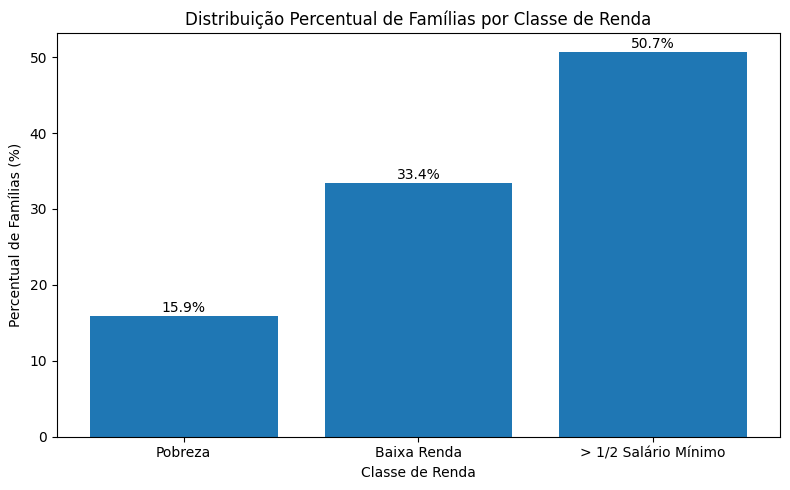

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Contar famílias únicas por classe de renda
familias_por_classe = (
    df.groupby('classe_renda')['ID_FAM_ANON']
      .nunique()
      .reset_index(name='qt_familias')
)

# 2) Calcular percentuais
total_familias = familias_por_classe['qt_familias'].sum()
familias_por_classe['percentual'] = (
    familias_por_classe['qt_familias'] / total_familias * 100
)

# 3) Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(
    familias_por_classe['classe_renda'],
    familias_por_classe['percentual']
)

# Rótulos e formatação
plt.xlabel("Classe de Renda")
plt.ylabel("Percentual de Famílias (%)")
plt.title("Distribuição Percentual de Famílias por Classe de Renda")
plt.xticks([0,1,2], ["Pobreza", "Baixa Renda", "> 1/2 Salário Mínimo"])

# Mostrar valores no topo das barras
for i, v in enumerate(familias_por_classe['percentual']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [29]:
mapeamento = {
    'NC1': 'IN_NECESSIDADE_CUIDADOS_1',  'NC2': 'IN_NECESSIDADE_CUIDADOS_2',
    'NC3': 'IN_NECESSIDADE_CUIDADOS_3',  'NC4': 'IN_NECESSIDADE_CUIDADOS_4',
    'NC5': 'IN_NECESSIDADE_CUIDADOS_5',  'NC6': 'IN_NECESSIDADE_CUIDADOS_6',
    'NC7': 'IN_NECESSIDADE_CUIDADOS_7',
    'DPI1': 'IN_DES_PRIMEIRA_INFANCIA_1', 'DPI2': 'IN_DES_PRIMEIRA_INFANCIA_2',
    'DPI3': 'IN_DES_PRIMEIRA_INFANCIA_3',
    'DCA1': 'IN_DES_CRIANCA_ADOLESCENTE_1', 'DCA2': 'IN_DES_CRIANCA_ADOLESCENTE_2',
    'DCA3': 'IN_DES_CRIANCA_ADOLESCENTE_3', 'DCA4': 'IN_DES_CRIANCA_ADOLESCENTE_4',
    'DCA5': 'IN_DES_CRIANCA_ADOLESCENTE_5',
    'TQA1': 'IN_TRAB_QUALIF_ADULTOS_1', 'TQA2': 'IN_TRAB_QUALIF_ADULTOS_2',
    'TQA3': 'IN_TRAB_QUALIF_ADULTOS_3', 'TQA4': 'IN_TRAB_QUALIF_ADULTOS_4',
    'TQA5': 'IN_TRAB_QUALIF_ADULTOS_5',
    'CH1':  'IN_CONDICOES_HABITACIONAIS_1',  'CH2':  'IN_CONDICOES_HABITACIONAIS_2',
    'CH5':  'IN_CONDICOES_HABITACIONAIS_5',  'CH6':  'IN_CONDICOES_HABITACIONAIS_6',
    'CH7':  'IN_CONDICOES_HABITACIONAIS_7',  'CH8':  'IN_CONDICOES_HABITACIONAIS_8',
    'CH9':  'IN_CONDICOES_HABITACIONAIS_9',  'CH10': 'IN_CONDICOES_HABITACIONAIS_10',
    'CH11': 'IN_CONDICOES_HABITACIONAIS_11', 'CH12': 'IN_CONDICOES_HABITACIONAIS_12',
    'CH13': 'IN_CONDICOES_HABITACIONAIS_13', 'CH14': 'IN_CONDICOES_HABITACIONAIS_14'
}

colunas_df = list(mapeamento.keys())

# Filtra classe 0 e 1
df_filtrado = df[df['classe_renda'].isin([0, 1])]

# Conta famílias com valor = 1 por classe_renda
resultado = (
    df_filtrado
    .groupby('classe_renda')[colunas_df]
    .apply(lambda g: (g == 1).sum())
    .T
    .rename(columns={0: 'classe_0', 1: 'classe_1'})
    .reset_index()
    .rename(columns={'index': 'indicador'})
)

# Aplica o mapeamento para exibir o nome equivalente do df1
resultado['indicador_df1'] = resultado['indicador'].map(mapeamento)

# Reordena colunas
resultado = resultado[['indicador', 'indicador_df1', 'classe_0', 'classe_1']]

print(resultado.to_string(index=False))

indicador                 indicador_df1  classe_0  classe_1
      NC1     IN_NECESSIDADE_CUIDADOS_1    366471    476926
      NC2     IN_NECESSIDADE_CUIDADOS_2    563818    874904
      NC3     IN_NECESSIDADE_CUIDADOS_3    831566   1515469
      NC4     IN_NECESSIDADE_CUIDADOS_4    108135    343882
      NC5     IN_NECESSIDADE_CUIDADOS_5     41494    160675
      NC6     IN_NECESSIDADE_CUIDADOS_6    779568   1382693
      NC7     IN_NECESSIDADE_CUIDADOS_7    875028   1680107
     DPI1    IN_DES_PRIMEIRA_INFANCIA_1     48238     97941
     DPI2    IN_DES_PRIMEIRA_INFANCIA_2    345635    468047
     DPI3    IN_DES_PRIMEIRA_INFANCIA_3     27230     48806
     DCA1  IN_DES_CRIANCA_ADOLESCENTE_1       303       349
     DCA2  IN_DES_CRIANCA_ADOLESCENTE_2      6487     11273
     DCA3  IN_DES_CRIANCA_ADOLESCENTE_3     10714     25745
     DCA4  IN_DES_CRIANCA_ADOLESCENTE_4    167896    307041
     DCA5  IN_DES_CRIANCA_ADOLESCENTE_5    215054    449061
     TQA1      IN_TRAB_QUALIF_ADULTOS_1 

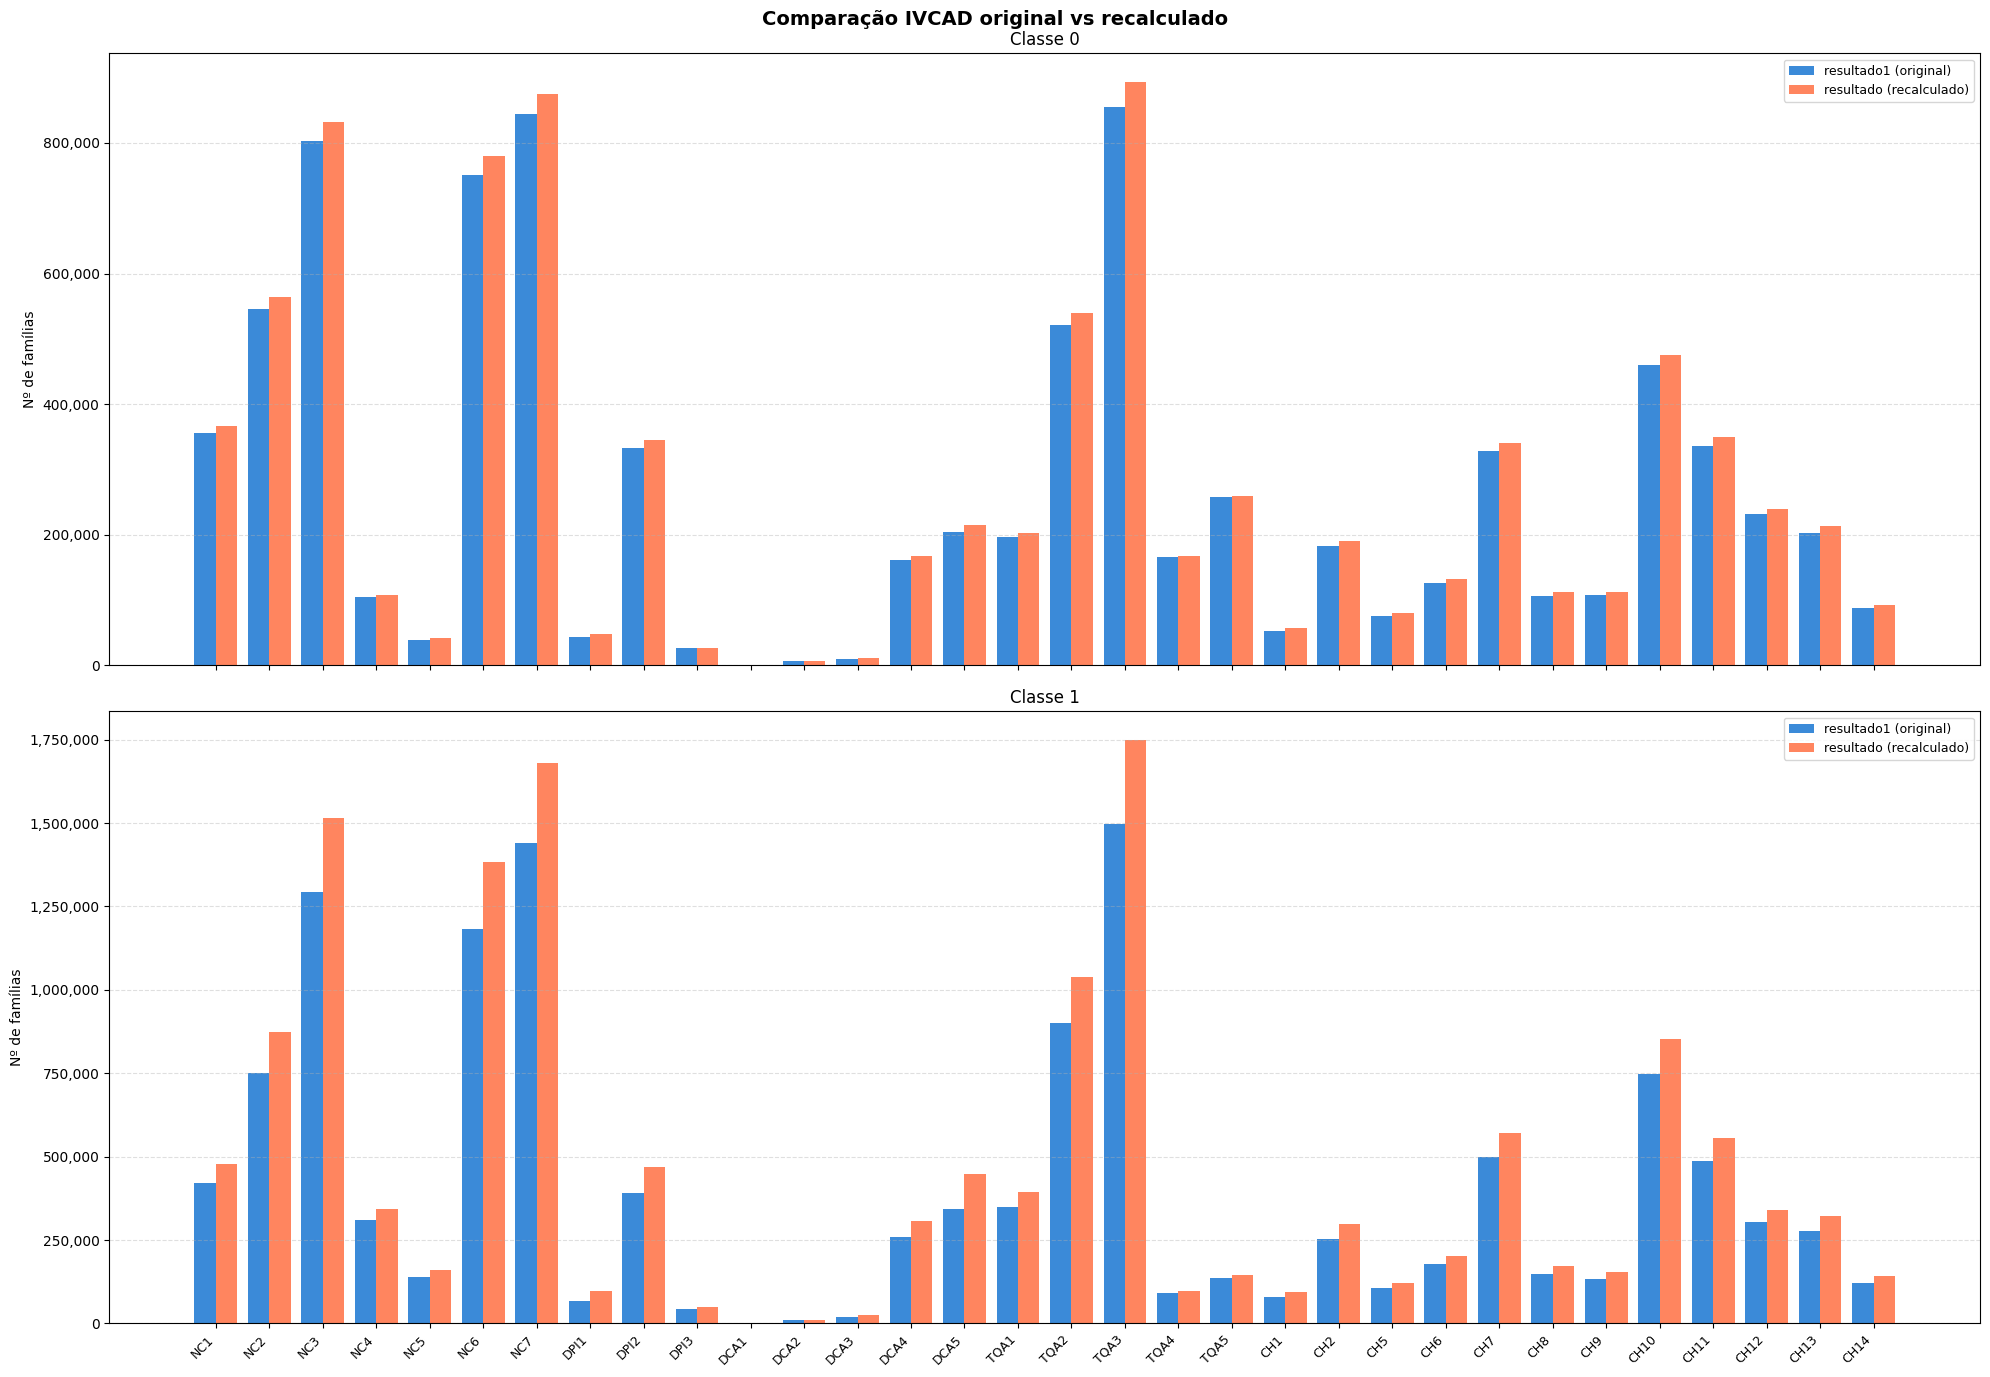

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── dados ────────────────────────────────────────────────────────────────────
resultado1 = pd.DataFrame({
    'indicador': [
        'IN_NECESSIDADE_CUIDADOS_1','IN_NECESSIDADE_CUIDADOS_2','IN_NECESSIDADE_CUIDADOS_3',
        'IN_NECESSIDADE_CUIDADOS_4','IN_NECESSIDADE_CUIDADOS_5','IN_NECESSIDADE_CUIDADOS_6',
        'IN_NECESSIDADE_CUIDADOS_7','IN_DES_PRIMEIRA_INFANCIA_1','IN_DES_PRIMEIRA_INFANCIA_2',
        'IN_DES_PRIMEIRA_INFANCIA_3','IN_DES_CRIANCA_ADOLESCENTE_1','IN_DES_CRIANCA_ADOLESCENTE_2',
        'IN_DES_CRIANCA_ADOLESCENTE_3','IN_DES_CRIANCA_ADOLESCENTE_4','IN_DES_CRIANCA_ADOLESCENTE_5',
        'IN_TRAB_QUALIF_ADULTOS_1','IN_TRAB_QUALIF_ADULTOS_2','IN_TRAB_QUALIF_ADULTOS_3',
        'IN_TRAB_QUALIF_ADULTOS_4','IN_TRAB_QUALIF_ADULTOS_5','IN_CONDICOES_HABITACIONAIS_1',
        'IN_CONDICOES_HABITACIONAIS_2','IN_CONDICOES_HABITACIONAIS_5','IN_CONDICOES_HABITACIONAIS_6',
        'IN_CONDICOES_HABITACIONAIS_7','IN_CONDICOES_HABITACIONAIS_8','IN_CONDICOES_HABITACIONAIS_9',
        'IN_CONDICOES_HABITACIONAIS_10','IN_CONDICOES_HABITACIONAIS_11','IN_CONDICOES_HABITACIONAIS_12',
        'IN_CONDICOES_HABITACIONAIS_13','IN_CONDICOES_HABITACIONAIS_14'
    ],
    'classe_0': [356173,545240,802341,104576,39669,750285,843666,44295,332698,26666,289,6398,10106,161320,204201,196840,520705,855673,166518,257245,53500,182544,75733,126156,327852,106544,108335,459647,336496,232478,202192,88077],
    'classe_1': [419436,752063,1293011,310164,140320,1182524,1440269,68308,389634,43800,322,10624,19946,259279,344404,348069,900769,1495517,90294,135330,80303,252378,105588,176719,500166,148396,134297,747269,486065,303578,277812,122064]
})

resultado = pd.DataFrame({
    'indicador_df1': resultado1['indicador'].tolist(),
    'classe_0': [366471,563818,831566,108135,41494,779568,875028,48238,345635,27230,303,6487,10714,167896,215054,203147,538936,892655,168059,259202,56785,191261,79770,131984,340080,111893,113028,475251,349154,239499,213003,92858],
    'classe_1': [476926,874904,1515469,343882,160675,1382693,1680107,97941,468047,48806,349,11273,25745,307041,449061,395351,1037606,1747468,97479,144865,93049,296623,121670,203016,571449,170878,153188,851668,555392,340884,322859,141281]
})

comp = resultado1.merge(resultado, left_on='indicador', right_on='indicador_df1')

rotulos_curtos = [
    'NC1','NC2','NC3','NC4','NC5','NC6','NC7',
    'DPI1','DPI2','DPI3',
    'DCA1','DCA2','DCA3','DCA4','DCA5',
    'TQA1','TQA2','TQA3','TQA4','TQA5',
    'CH1','CH2','CH5','CH6','CH7','CH8','CH9','CH10','CH11','CH12','CH13','CH14'
]

# ── gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharex=True)
fig.suptitle('Comparação IVCAD original vs recalculado', fontsize=14, fontweight='bold')

x     = np.arange(len(comp))
width = 0.4

for ax, cls, titulo in [
    (axes[0], 'classe_0', 'Classe 0'),
    (axes[1], 'classe_1', 'Classe 1'),
]:
    v1 = comp[f'{cls}_x'].values
    v2 = comp[f'{cls}_y'].values

    b1 = ax.bar(x - width/2, v1, width, label='resultado1 (original)', color='#1976D2', alpha=0.85)
    b2 = ax.bar(x + width/2, v2, width, label='resultado (recalculado)', color='#FF7043', alpha=0.85)

    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('Nº de famílias')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.set_xticks(x)
    ax.set_xticklabels(rotulos_curtos, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [35]:
# Variável-alvo binária para o modelo (triagem)
# 0 = até 1/2 salário mínimo 
# 1 = proxy de renda provável acima do limiar, usada para identificar potenciais inconsistências

df['y_bin'] = np.where(
    df['VL_RENDA_MEDIA_FAM'] > 759,
    1,
    0
)


In [36]:
df['classe_risco_qualificacao'] = np.where(
    df['y_bin'] == 1,
    'renda formal per capita (CNIS) > ½ SM',
    'renda formal per capita (CNIS) ≤ ½ SM'
)


In [37]:
df.head()

,ID_FAM_ANON,REF_CAD,IBGE_REG,IBGE_UF,IBGE_MUN,VL_RENDA_MEDIA_FAM,NC1,NC2,NC3,NC4,...,CH8,CH9,CH10,CH11,CH12,CH13,CH14,classe_renda,y_bin,classe_risco_qualificacao
0,1,202511,1,11,1100205,0.0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,renda formal per capita (CNIS) ≤ ½ SM
1,2,202511,1,11,1100205,1064.0,0,0,0,0,...,1,1,1,1,1,1,1,2,1,renda formal per capita (CNIS) > ½ SM
2,3,202511,1,11,1100106,547.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,renda formal per capita (CNIS) ≤ ½ SM
3,4,202511,1,11,1100155,1997.0,0,0,0,0,...,0,0,1,0,0,0,0,2,1,renda formal per capita (CNIS) > ½ SM
4,5,202511,1,11,1100304,1443.0,0,0,0,0,...,0,0,1,0,0,0,0,2,1,renda formal per capita (CNIS) > ½ SM


In [38]:
df.shape

(8308820, 41)

In [39]:
df.columns

Index(['ID_FAM_ANON', 'REF_CAD', 'IBGE_REG', 'IBGE_UF', 'IBGE_MUN',
       'VL_RENDA_MEDIA_FAM', 'NC1', 'NC2', 'NC3', 'NC4', 'NC5', 'NC6', 'NC7',
       'DPI1', 'DPI2', 'DPI3', 'DCA1', 'DCA2', 'DCA3', 'DCA4', 'DCA5', 'TQA1',
       'TQA2', 'TQA3', 'TQA4', 'TQA5', 'CH1', 'CH2', 'CH5', 'CH6', 'CH7',
       'CH8', 'CH9', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'classe_renda',
       'y_bin', 'classe_risco_qualificacao'],
      dtype='object')

In [40]:
import pandas as pd
import numpy as np

# Tamanho total desejado para a amostra binária
N = 1_000_000
SEED = 42

# ------------------------------------------------------------
# 0) Checagens básicas
# ------------------------------------------------------------
cols_necessarias = ["classe_renda", "y_bin", "classe_risco_qualificacao"]
faltantes = [c for c in cols_necessarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas no df: {faltantes}")

# ------------------------------------------------------------
# 1) Distribuições na base original 
# ------------------------------------------------------------

print("\nDistribuição de classe_renda (0=pobreza, 1=baixa renda, 2=acima 1/2 SM):")
dist_classe = df["classe_renda"].value_counts(dropna=False).sort_index()
print(dist_classe)

print("\nDistribuição de y_bin (0=até 1/2 SM, 1=acima):")
dist_y = df["y_bin"].value_counts(dropna=False).sort_index()
print(dist_y)

print("\nDistribuição de classe_risco_qualificacao:")
dist_risco = df["classe_risco_qualificacao"].value_counts(dropna=False)
print(dist_risco)

print("\nCrosstab: classe_renda x y_bin (checar consistência dos cortes):")
print(pd.crosstab(df["classe_renda"], df["y_bin"], dropna=False))

print("\nCrosstab: classe_risco_qualificacao x y_bin:")
print(pd.crosstab(df["classe_risco_qualificacao"], df["y_bin"], dropna=False))

# percentuais gerais
print("\nPercentuais (base original):")
print("classe_renda (%):")
print((dist_classe / len(df) * 100).round(2))
print("\ny_bin (%):")
print((dist_y / len(df) * 100).round(2))

# ------------------------------------------------------------
# 2) Amostragem BALANCEADA por y_bin -> df_bal_binario
# ------------------------------------------------------------
n_por_classe = N // 2

vcb = df["y_bin"].dropna().value_counts().sort_index()
if (vcb < n_por_classe).any():
    raise ValueError(
        f"Alguma classe de y_bin não tem linhas suficientes para amostrar {n_por_classe} por classe.\n"
        f"Counts:\n{vcb}"
    )

amostras = []
for i, yval in enumerate(sorted(df["y_bin"].dropna().unique())):
    amostras.append(
        df[df["y_bin"] == yval].sample(n=n_por_classe, random_state=SEED + i)
    )

df_bal_binario = (
    pd.concat(amostras, axis=0)
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) Distribuições no df_bal_binario
# ------------------------------------------------------------
print("\n\n=== AMOSTRA FINAL (df_bal_binario - balanceada por y_bin) ===")

dist_y_bal = df_bal_binario["y_bin"].value_counts(dropna=False).sort_index()
dist_classe_bal = df_bal_binario["classe_renda"].value_counts(dropna=False).sort_index()
dist_risco_bal = df_bal_binario["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de y_bin no df_bal_binario:")
print(dist_y_bal)

print("\nDistribuição de classe_renda (0/1/2) dentro do df_bal_binario:")
print(dist_classe_bal)

print("\nDistribuição de classe_risco_qualificacao no df_bal_binario:")
print(dist_risco_bal)

print("\nCrosstab: classe_renda x y_bin no df_bal_binario:")
print(pd.crosstab(df_bal_binario["classe_renda"], df_bal_binario["y_bin"], dropna=False))

print("\nCrosstab: classe_risco_qualificacao x y_bin no df_bal_binario:")
print(pd.crosstab(df_bal_binario["classe_risco_qualificacao"], df_bal_binario["y_bin"], dropna=False))

print("\nPercentuais (df_bal_binario):")
print("classe_renda (%):")
print((dist_classe_bal / len(df_bal_binario) * 100).round(2))
print("\ny_bin (%):")
print((dist_y_bal / len(df_bal_binario) * 100).round(2))

print("\nShape do df_bal_binario:")
print(df_bal_binario.shape)



Distribuição de classe_renda (0=pobreza, 1=baixa renda, 2=acima 1/2 SM):
classe_renda
0    1322126
1    2777215
2    4209479
Name: count, dtype: int64

Distribuição de y_bin (0=até 1/2 SM, 1=acima):
y_bin
0    4099341
1    4209479
Name: count, dtype: int64

Distribuição de classe_risco_qualificacao:
classe_risco_qualificacao
renda formal per capita (CNIS) > ½ SM    4209479
renda formal per capita (CNIS) ≤ ½ SM    4099341
Name: count, dtype: int64

Crosstab: classe_renda x y_bin (checar consistência dos cortes):
y_bin               0        1
classe_renda                  
0             1322126        0
1             2777215        0
2                   0  4209479

Crosstab: classe_risco_qualificacao x y_bin:
y_bin                                        0        1
classe_risco_qualificacao                              
renda formal per capita (CNIS) > ½ SM        0  4209479
renda formal per capita (CNIS) ≤ ½ SM  4099341        0

Percentuais (base original):
classe_renda (%):
classe_re

In [41]:
df_bal_binario_ivcad = df_bal_binario.to_csv("df_bal_binario_ivcad.csv", index=False, encoding="utf-8")

In [42]:
import pandas as pd
import numpy as np

# Tamanho total desejado para a amostra
N = 1_000_000
SEED = 42  # reprodutível

# ------------------------------------------------------------
# 0) Checagens
# ------------------------------------------------------------
cols_necessarias = ["classe_renda", "y_bin", "classe_risco_qualificacao"]
faltantes = [c for c in cols_necessarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas no df: {faltantes}")

# ------------------------------------------------------------
# 1) Distribuições na base original 
# ------------------------------------------------------------

dist_classe = df["classe_renda"].value_counts(dropna=False).sort_index()
dist_y = df["y_bin"].value_counts(dropna=False).sort_index()
dist_risco = df["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de classe_renda (0/1/2):")
print(dist_classe)

print("\nDistribuição de y_bin (0/1):")
print(dist_y)

print("\nDistribuição de classe_risco_qualificacao:")
print(dist_risco)

print("\nCrosstab: classe_renda x y_bin (base original):")
print(pd.crosstab(df["classe_renda"], df["y_bin"], dropna=False))

# ------------------------------------------------------------
# 2) AMOSTRA PROPORCIONAL À DISTRIBUIÇÃO ORIGINAL DE y_bin
# ------------------------------------------------------------
vc = df["y_bin"].value_counts().sort_index()
proporcoes = vc / vc.sum()

# Número de casos por classe (aprox), garantindo soma = N
n_por_classe_prop = (proporcoes * N).round().astype(int)

# Ajuste fino para garantir soma exatamente N (por arredondamento)
diferenca = N - n_por_classe_prop.sum()
if diferenca != 0:
    ordem_ajuste = vc.sort_values(ascending=False).index.tolist()
    idx = 0
    passo = 1 if diferenca > 0 else -1
    for _ in range(abs(diferenca)):
        classe_ajustar = ordem_ajuste[idx % len(ordem_ajuste)]
        n_por_classe_prop[classe_ajustar] += passo
        idx += 1

print("\nTamanho por classe (y_bin) na amostra proporcional:")
print(n_por_classe_prop, " (soma:", int(n_por_classe_prop.sum()), ")")

# Verificar se há linhas suficientes para cada classe binária
vc_disp = df["y_bin"].value_counts().sort_index()
if (vc_disp < n_por_classe_prop).any():
    faltam = (n_por_classe_prop - vc_disp)[(n_por_classe_prop - vc_disp) > 0]
    raise ValueError(
        "Alguma classe de y_bin não tem linhas suficientes para a amostragem proporcional.\n"
        f"Faltando:\n{faltam}\n"
        f"Disponível:\n{vc_disp}\n"
        f"Solicitado:\n{n_por_classe_prop}"
    )

# Amostragem proporcional por y_bin
amostras_prop = []
for i, (yval, n_cls) in enumerate(n_por_classe_prop.items()):
    amostra_classe = df[df["y_bin"] == yval].sample(
        n=int(n_cls),
        random_state=SEED + 100 + i
    )
    amostras_prop.append(amostra_classe)

df_prop_binario = (
    pd.concat(amostras_prop, axis=0)
      .sample(frac=1, random_state=SEED + 999)
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3) Distribuições na amostra proporcional binária
# ------------------------------------------------------------
print("\n=== AMOSTRA FINAL (df_prop_binario - proporcional por y_bin) ===")

dist_y_prop = df_prop_binario["y_bin"].value_counts(dropna=False).sort_index()
dist_classe_prop = df_prop_binario["classe_renda"].value_counts(dropna=False).sort_index()
dist_risco_prop = df_prop_binario["classe_risco_qualificacao"].value_counts(dropna=False)

print("\nDistribuição de y_bin no df_prop_binario:")
print(dist_y_prop)

print("\nDistribuição de classe_renda (0/1/2) dentro do df_prop_binario:")
print(dist_classe_prop)

print("\nDistribuição de classe_risco_qualificacao no df_prop_binario:")
print(dist_risco_prop)

print("\nCrosstab: classe_renda x y_bin no df_prop_binario:")
print(pd.crosstab(df_prop_binario["classe_renda"], df_prop_binario["y_bin"], dropna=False))

print("\nShape do df_prop_binario:")
print(df_prop_binario.shape)




Distribuição de classe_renda (0/1/2):
classe_renda
0    1322126
1    2777215
2    4209479
Name: count, dtype: int64

Distribuição de y_bin (0/1):
y_bin
0    4099341
1    4209479
Name: count, dtype: int64

Distribuição de classe_risco_qualificacao:
classe_risco_qualificacao
renda formal per capita (CNIS) > ½ SM    4209479
renda formal per capita (CNIS) ≤ ½ SM    4099341
Name: count, dtype: int64

Crosstab: classe_renda x y_bin (base original):
y_bin               0        1
classe_renda                  
0             1322126        0
1             2777215        0
2                   0  4209479

Tamanho por classe (y_bin) na amostra proporcional:
y_bin
0    493372
1    506628
Name: count, dtype: int64  (soma: 1000000 )

=== AMOSTRA FINAL (df_prop_binario - proporcional por y_bin) ===

Distribuição de y_bin no df_prop_binario:
y_bin
0    493372
1    506628
Name: count, dtype: int64

Distribuição de classe_renda (0/1/2) dentro do df_prop_binario:
classe_renda
0    158773
1    334599
2  

In [43]:
# Salvar amostra proporcional
df_prop_binario_ivcad = df_prop_binario.to_csv("df_prop_binario_ivcad.csv", index=False, encoding="utf-8")